# Patterns In Youth Marijuana Use: Understanding Drug Usage in Minors through Decision Trees and Ensemble Methods

The following project is designed to determine which factors are most correlated with youth usage of marijuana, specifically with respect to demography (race, sex, household income, etc.) and parental influence (attitudes about drug use, level of involvement, etc.). To accomplish this, three separate approaches were taken using decision trees and ensemble methods to answer the following questions:

1) **Binary classification**: Which factors relate to whether a respondent has ever smoked marijuana or not?
2) **Multi-class classification**: Which factors relate to whether a respondent has smoked in the past year? (has not, has but not in the past year, has smoked in the past year)
3) **Regression**: Which factors relate to the age at which a respondent first used marijuana, if at all?

The data utilized for this project is sourced from the National Survey on Drug Use and Health, and contains a wide variety of responses to survey questions regarding the respondents' demographic backgrounds, usage/attitudes of drugs, and parental/peer influence. The data has previously been preprocessed to have all responses converted into a numerical format for the ease of analysis. Additionally, the dataset, which originally comprised upwards of 30,000 responses across 3,000 questions has been reduced to a more manageable size of around 10,000 responses and 79 total features (questions). This reduction also included filtering out all responses from those aged 18 and older.

Link to dataset:
https://www.samhsa.gov/data/data-we-collect/nsduh-national-survey-drug-use-and-health/datafiles/2023

## Import necessary libraries

In [193]:
# Installing scikit-learn
!pip install -Uqq scikit-learn

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix as confusion_matrix_sklearn
from sklearn.inspection import PartialDependenceDisplay

## Generate DataFrame and Prepare Data for Model Analysis

In [194]:
df = pd.read_csv('C:/Users/jacob/Downloads/youth_data.csv') # load youth data and create pandas DataFrame
df.info() # inspect data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10561 entries, 0 to 10560
Data columns (total 79 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IRALCFY      10561 non-null  int64  
 1   IRMJFY       10561 non-null  int64  
 2   IRCIGFM      10561 non-null  float64
 3   IRSMKLSS30N  10561 non-null  int64  
 4   IRALCFM      10561 non-null  float64
 5   IRMJFM       10561 non-null  float64
 6   IRCIGAGE     10561 non-null  int64  
 7   IRSMKLSSTRY  10561 non-null  int64  
 8   IRALCAGE     10561 non-null  int64  
 9   IRMJAGE      10561 non-null  int64  
 10  MRJFLAG      10561 non-null  int64  
 11  ALCFLAG      10561 non-null  int64  
 12  TOBFLAG      10561 non-null  int64  
 13  ALCYDAYS     10561 non-null  int64  
 14  MRJYDAYS     10561 non-null  int64  
 15  ALCMDAYS     10561 non-null  int64  
 16  MRJMDAYS     10561 non-null  int64  
 17  CIGMDAYS     10561 non-null  int64  
 18  SMKLSMDAYS   10561 non-null  int64  
 19  SCHF

The code below defines a list of 14 predictor variables of interest that could capture the influence demographics and parental influence have on marijuana usage. Specific considerations were made to exclude variables that could potentially exhibit multicollinearity with others (e.g. INCOME (household income) and POVERTY3 (household proximity to poverty level)). The target variables of interest are the following: has the respondent ever used marijuana ('MRJFLAG'), how frequently have they used marijuana in the past year ('IRMJFY'), and at what age did they first use marijuana ('IRMJAGE'). Each of these target variables will be reserved individually for modelling approach.

In [195]:
# generate list of predictor variables
predictors = ['IRSEX', 'NEWRACE2', 'INCOME', 'COUTYP4', 'RLGATTD', 'EDUSCHGRD2', 'PRMJEVR2', 'PRVDRGO2', 'ARGUPAR', 'PARCHKHW', 'PARHLPHW', 'PRLMTTV2', 'PARLMTSN', 'PRPROUD2']

df1 = df[predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']].dropna() # drop all null values for predictors and target variables

# define predictor variables and target variable
X = df1[predictors]
y = df1['MRJFLAG']

## Exploratory Data Analysis

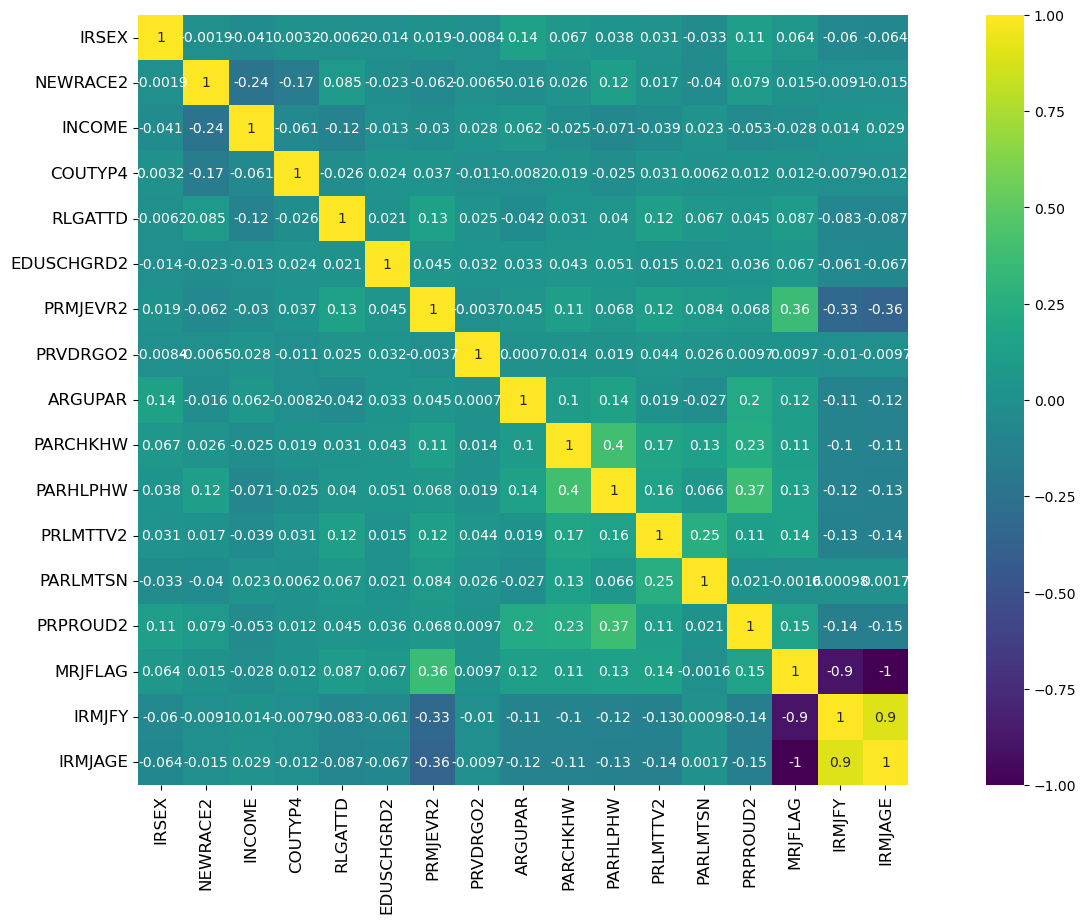

In [196]:
corr_matrix = df1[predictors + ['MRJFLAG', 'IRMJFY', 'IRMJAGE']].corr()

plt.figure(figsize=(20,10))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap='viridis'
)

plt.tick_params(labelsize=12)

plt.show()

The correlation matrix conveys that the variable with the greatest correlation coefficients relative to the target variables of interest is PRMJEVR2, which was a survey question investigating parental attitudes around youth trying marijuana.  

## Binary Classification: Has the respondent ever used marijuana?

In assessing the factors that are most relevant for whether a respondent has ever used marijuana, four separate models were applied. These included a standard decision tree model along with all three ensemble methods - bagging, random forest, and boosting. All four were applied for this formulation given the simplicity of two potential outcomes for the target variable, and to allow for the most direct comparison between all model types.

In [197]:
df1['MRJFLAG'].value_counts() # examine class distribution for binary target variable

MRJFLAG
0    8289
1    1521
Name: count, dtype: int64

### Applying Decision Tree Model

The code below splits the dataset into training and test sets representing 80 and 20% of data points, respectively. A Decision Tree Classifer is then applied to the training data and inspected for the most important features and its number of terminal nodes. This model is then used to generate predictions on the test data and examined for its accuracy.

In [198]:
# split the data between test and train
X_train, X_test, y_train, y_test = train_test_split(X, y
                                                    , train_size=0.8
                                                    , random_state=1)

# fit decision tree model
tree_df1 = DecisionTreeClassifier(random_state=1)
tree_df1.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [199]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': tree_df1.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.158043
1      PRMJEVR2    0.152351
2      NEWRACE2    0.111793
3        INCOME    0.109377
4       COUTYP4    0.097088
5         IRSEX    0.058588
6      PARCHKHW    0.055881
7       RLGATTD    0.051175
8      PARHLPHW    0.049641
9      PARLMTSN    0.037934
10      ARGUPAR    0.037433
11     PRVDRGO2    0.030228
12     PRLMTTV2    0.025816
13     PRPROUD2    0.024651


In [200]:
tree_df1.get_n_leaves()

np.int64(1853)

In [201]:
# predict on test data
tree_pred = tree_df1.predict(X_test)

# create confusion matrix
confusion_matrix_tree = pd.crosstab(index=tree_pred, columns=y_test, rownames=[''])
print(confusion_matrix_tree)

# calculate test accuracy and error rate
test_accuracy = tree_df1.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy)*100))

MRJFLAG     0    1
                  
0        1458  196
1         208  100
Accuracy: 79.41%
Error Rate: 20.59%


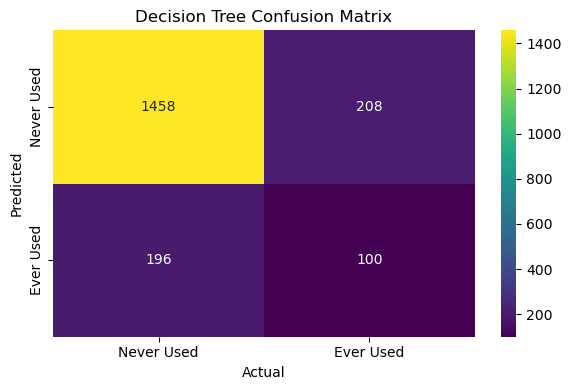

In [202]:
# generate confusion matrix using seaborn
cm = confusion_matrix_sklearn(y_test, tree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

Using cross-validation, the optimal number of terminal nodes is determined and used to generate a pruned decision tree model. This pruned model is then plotted, applied to the data, and assessed for its accuracy relative to the unpruned model.

In [203]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 50)}
cv_df1 = GridSearchCV(tree_df1, params, cv=10)
cv_df1.fit(X_train, y_train)
cv_results = cv_df1.cv_results_

# find the best score for max leaf nodes
best_size = cv_df1.best_params_['max_leaf_nodes']
best_score = cv_df1.best_score_

best_size

8

Text(0.5, 1.0, 'Tree Size vs. Cross-Validated Classification Error Rate')

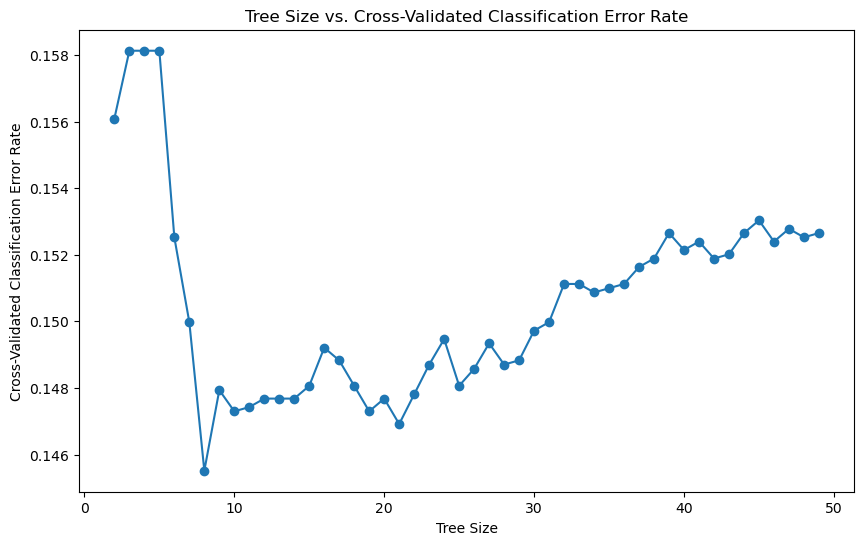

In [204]:
# plot tree size vs cross-validated classification error rate
cv_error_rate = 1 - cv_results['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(cv_results["param_max_leaf_nodes"], cv_error_rate, marker='o')
plt.xlabel('Tree Size')
plt.ylabel('Cross-Validated Classification Error Rate')
plt.title('Tree Size vs. Cross-Validated Classification Error Rate')

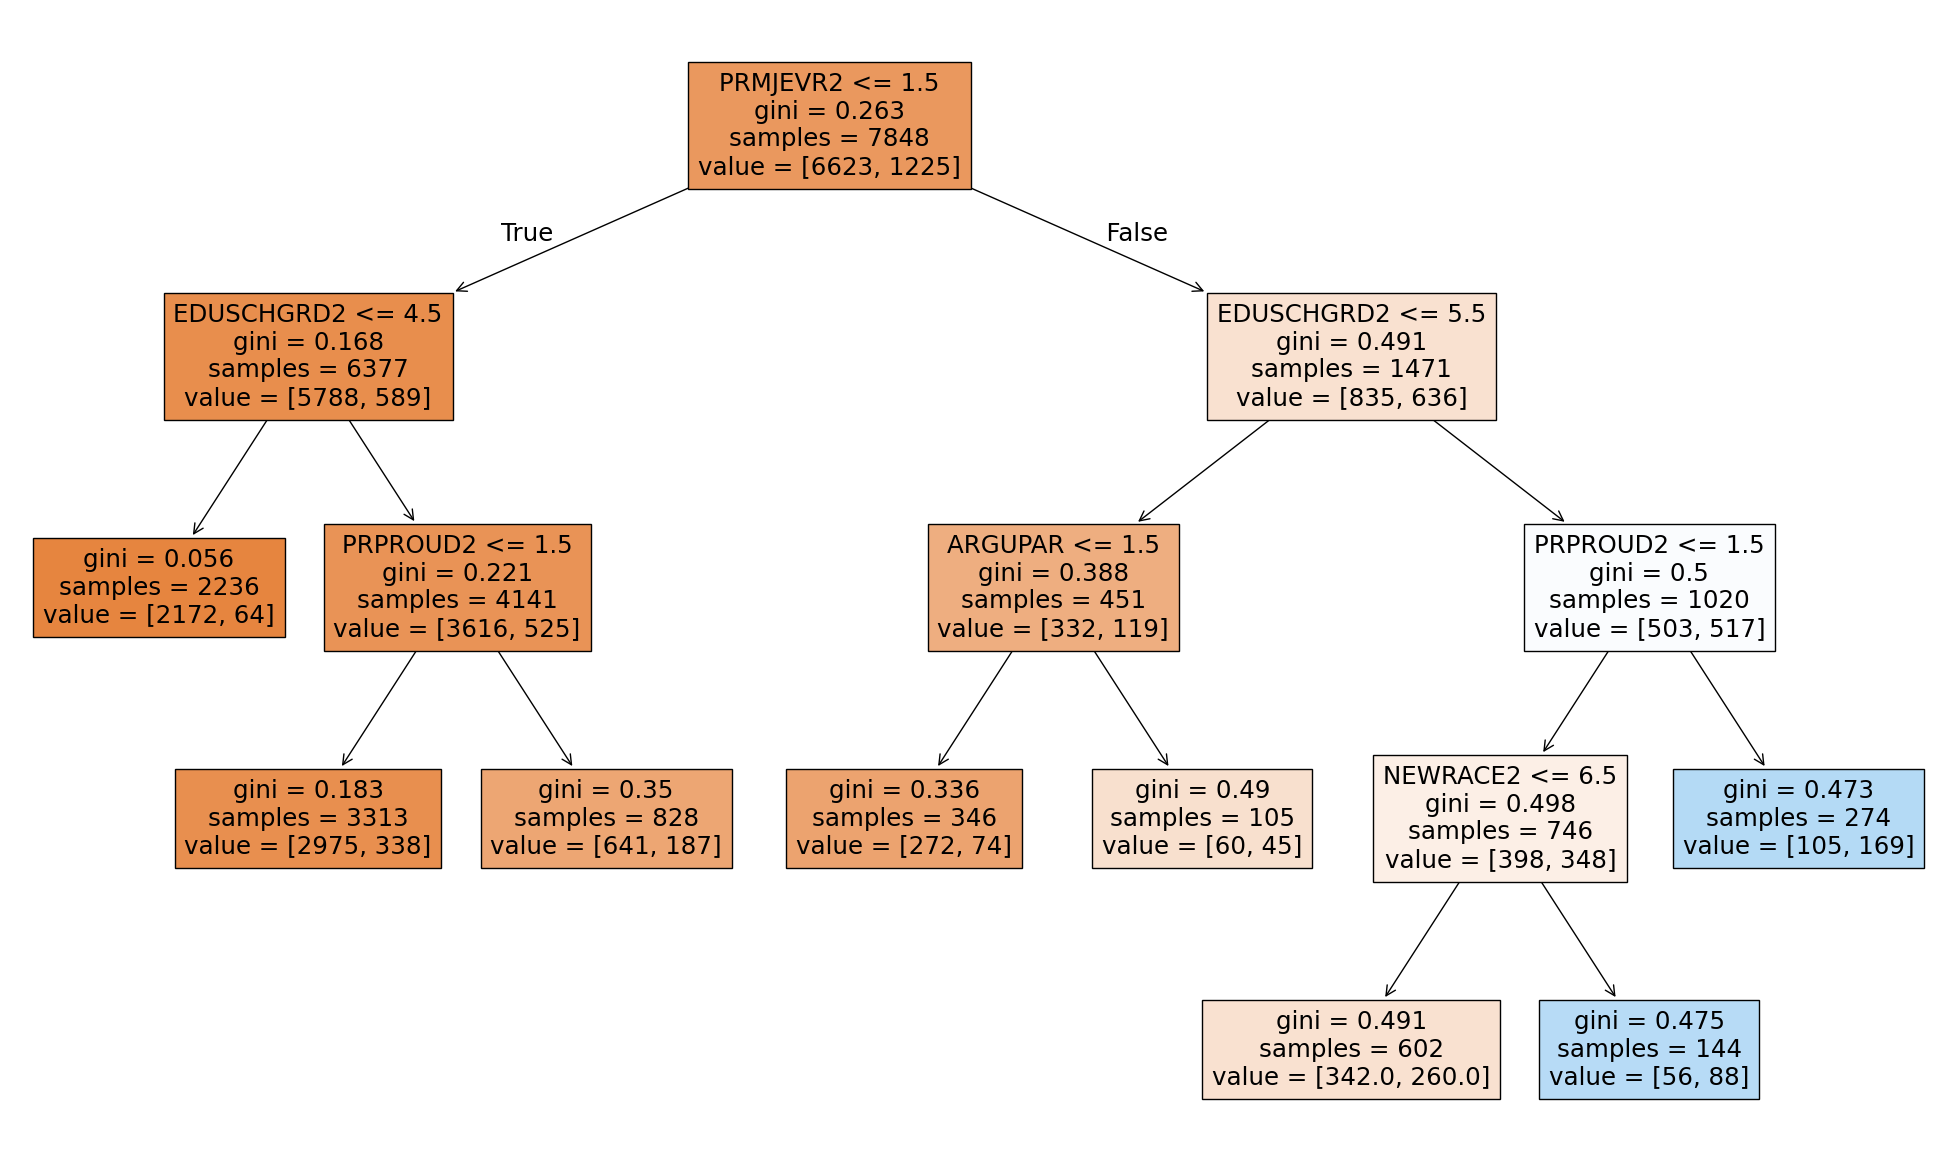

In [205]:
# prune tree using optimal size
prune_df1 = DecisionTreeClassifier(max_leaf_nodes=best_size, random_state=1)
prune_df1.fit(X_train, y_train)

# plot pruned tree
plt.figure(figsize=(25, 15))
plt.title('Pruned Tree')
plot_tree(prune_df1, feature_names=X_train.columns, filled = True);

In [206]:
# predict on test data
pruned_tree_pred = prune_df1.predict(X_test)

# create confusion matrix
confusion_matrix_tree = pd.crosstab(index=pruned_tree_pred, columns=y_test, rownames=[''])
print(confusion_matrix_tree)

# calculate test accuracy and error rate
test_accuracy = prune_df1.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy)*100))

MRJFLAG     0    1
                  
0        1620  234
1          46   62
Accuracy: 85.73%
Error Rate: 14.27%


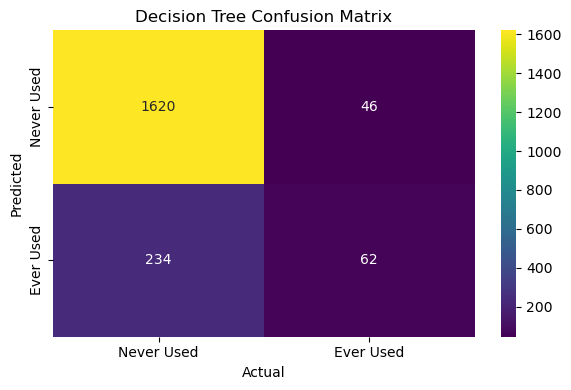

In [207]:
# generate confusion matrix using seaborn
cm_prune = confusion_matrix_sklearn(y_test, pruned_tree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_prune, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

This pruned model outperformed its unpruned counterpart with an accuracy of 85.73% compared to the unpruned model's accuracy of 79.41%. The pruned model is then assessed for the feature importances of each of the predictor variables.

In [208]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': prune_df1.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.716815
1    EDUSCHGRD2    0.168382
2      PRPROUD2    0.076177
3      NEWRACE2    0.019363
4       ARGUPAR    0.019264
5         IRSEX    0.000000
6        INCOME    0.000000
7       COUTYP4    0.000000
8       RLGATTD    0.000000
9      PRVDRGO2    0.000000
10     PARCHKHW    0.000000
11     PARHLPHW    0.000000
12     PRLMTTV2    0.000000
13     PARLMTSN    0.000000


Compared to the unpruned model, which saw little disparity between its top features in terms of importance score, the pruned model was dominated by the PRMJEVR2 variable by a wide margin. This result is expected for a decision tree model whose greedy, top-down algorithm can tend to emphasize features that result in the greatest level of node purity upon splitting.

### Applying Bagging Model

A Random Forest Classifer is then applied to the same training data and inspected for the most important features as well as its training score. This bagging model is then used to generate predictions on the test data and examined for its accuracy and error rate.

In [209]:
# fit Random Forests model
df1_bagging = RandomForestClassifier(max_features=X_train.shape[1],random_state = 1)
df1_bagging.fit(X_train, y_train)

print("Number of trees:", df1_bagging.n_estimators)
print("Number of features tried at each split:", df1_bagging.max_features)
print("Training score: {:.2f}%".format(df1_bagging.score(X_train, y_train)*100))

Number of trees: 100
Number of features tried at each split: 14
Training score: 97.27%


In [210]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': df1_bagging.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.162604
1      PRMJEVR2    0.146111
2      NEWRACE2    0.112744
3        INCOME    0.109084
4       COUTYP4    0.091911
5         IRSEX    0.058969
6      PARLMTSN    0.052966
7      PARCHKHW    0.049907
8      PARHLPHW    0.043212
9       RLGATTD    0.043149
10      ARGUPAR    0.038639
11     PRLMTTV2    0.037360
12     PRPROUD2    0.028576
13     PRVDRGO2    0.024767


In [211]:
# Predict values
y_pred_bag = df1_bagging.predict(X_test)

# create confusion matrix
confusion_matrix_bag = pd.crosstab(index=y_pred_bag, columns=y_test, rownames=[''])
print(confusion_matrix_bag)

# calculate test accuracy and error rate
test_accuracy_bag = df1_bagging.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy_bag*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_bag)*100))

MRJFLAG     0    1
                  
0        1555  202
1         111   94
Accuracy: 84.05%
Error Rate: 15.95%


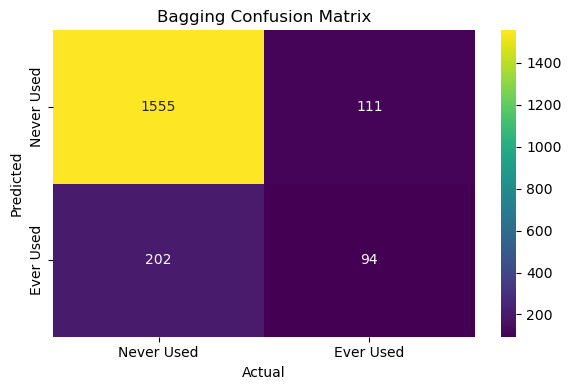

In [212]:
# generate confusion matrix using seaborn
cm_bag = confusion_matrix_sklearn(y_test, y_pred_bag)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_bag, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Bagging Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

Based on the feature importance output, the top features for predicting marijuana usage include grade level (EDUSCHGRD2), PRMJEVR2 (parental attitudes around youth using marijuana), NEWRACE2 (race/ethnicity), and income (household income level). The bagging model was slightly less accurate in its predictions compared to the pruned decision tree, however it correctly identified more respondents who had used marijuana. 

### Applying Random Forest Model

A Random Forest Classifer is again applied to the same training data and inspected for the most important features as well as its training score. This random forest model considers half of the predictors and is then used to generate predictions on the test data and examined for its accuracy and error rate.

In [213]:
# fit Random Forests model
df1_rf = RandomForestClassifier(max_features=7 # reduce features to half of total amount
                                       ,random_state = 1)

df1_rf.fit(X_train,y_train)

print("Number of trees:", df1_rf.n_estimators)
print("Number of features tried at each split:", df1_rf.max_features)
print("Training score: {:.2f}%".format(df1_rf.score(X_train, y_train)*100))

Number of trees: 100
Number of features tried at each split: 7
Training score: 97.27%


In [214]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': df1_rf.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.174809
1      PRMJEVR2    0.138838
2      NEWRACE2    0.116926
3        INCOME    0.114570
4       COUTYP4    0.090242
5         IRSEX    0.057415
6      PARLMTSN    0.052668
7      PARCHKHW    0.046896
8       RLGATTD    0.041983
9       ARGUPAR    0.038355
10     PARHLPHW    0.037502
11     PRLMTTV2    0.034525
12     PRPROUD2    0.030376
13     PRVDRGO2    0.024893


In [215]:
# Predict values
y_pred_rf = df1_rf.predict(X_test)

# create confusion matrix
confusion_matrix_rf = pd.crosstab(index=y_pred_rf, columns=y_test, rownames=[''])
print(confusion_matrix_rf)

# calculate test accuracy and error rate
test_accuracy_rf = df1_rf.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy_rf*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_rf)*100))

MRJFLAG     0    1
                  
0        1574  200
1          92   96
Accuracy: 85.12%
Error Rate: 14.88%


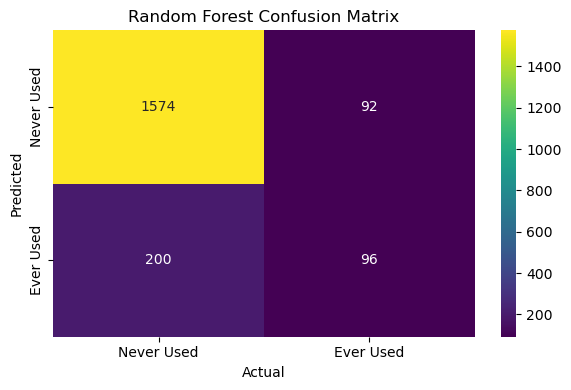

In [216]:
# generate confusion matrix using seaborn
cm_rf = confusion_matrix_sklearn(y_test, y_pred_rf)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

According to the feature importance output, the top features for predicting marijuana usage include grade level (EDUSCHGRD2), PRMJEVR2 (parental attitudes around youth using marijuana), NEWRACE2 (race/ethnicity), and income (household income level). The random forest model's accuracy fell between the pruned decision tree model and the bagging model, however it correctly identified more respondents who had used marijuana than either.

### Applying Boosting Model

A Gradient Boosting Classifer is applied to the same training data and inspected for the most important features. This model is then used to generate predictions on the test data and examined for its accuracy and error rate.

In [217]:
boost_df1 = GradientBoostingClassifier(n_estimators=1000  # use 1,000 trees
                                              , learning_rate = 0.1 # default shrinkage parameter
                                              , max_depth = 4
                                              , random_state = 1)

boost_df1.fit(X_train, y_train) # fit model to training data

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [218]:
importances = pd.DataFrame({'feature_name': X.columns, 'importance': boost_df1.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.357836
1    EDUSCHGRD2    0.177120
2      NEWRACE2    0.076670
3        INCOME    0.057495
4      PRPROUD2    0.056907
5       ARGUPAR    0.042693
6       COUTYP4    0.040361
7      PRLMTTV2    0.034038
8      PARLMTSN    0.033029
9      PARHLPHW    0.031049
10     PARCHKHW    0.028246
11        IRSEX    0.028130
12      RLGATTD    0.022895
13     PRVDRGO2    0.013531


In [219]:
# Predict values
y_pred_boost = boost_df1.predict(X_test)

# create confusion matrix
confusion_matrix_boost = pd.crosstab(index=y_pred_boost, columns=y_test, rownames=[''])
print(confusion_matrix_boost)

# calculate test accuracy and error rate
test_accuracy_boost = boost_df1.score(X_test, y_test)
print("Accuracy: {:.2f}%".format(test_accuracy_boost*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_boost)*100))

MRJFLAG     0    1
                  
0        1577  210
1          89   86
Accuracy: 84.76%
Error Rate: 15.24%


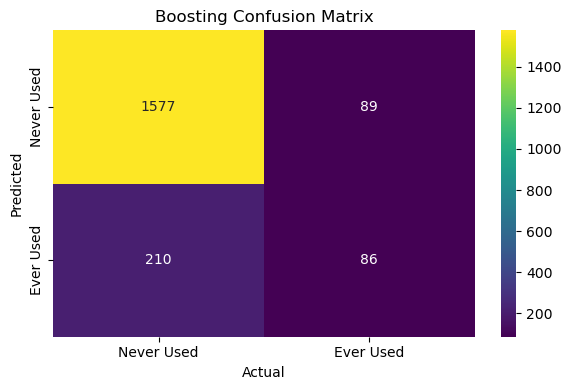

In [220]:
# generate confusion matrix using seaborn
cm_boost = confusion_matrix_sklearn(y_test, y_pred_boost)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_boost, annot=True, fmt='d', xticklabels=['Never Used', 'Ever Used'], yticklabels=['Never Used', 'Ever Used'], cmap='viridis')
plt.title('Boosting Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

The top features for predicting marijuana usage are again grade level (EDUSCHGRD2), PRMJEVR2 (parental attitudes around youth using marijuana), NEWRACE2 (race/ethnicity), and income (household income level), with PRMJEVR2 exhibiting the greatest importance by a wider margin compared to previous models. The boosting model's accuracy fell between the bagging model and the random forest model.

## Multi-Class Classification: How frequently does the respondent use marijuana?

For multi-class classification, a standard decision tree model and random forest model are compared for their ability to accurately predict between three target classes of marijuana usage: having used in the past year, having used but not in the past year, and having not used at all.

The code below first assigns numerical labels for the three classes: 0 if the respondent has never used marijuana, 1 if they have not used marijuana in the past year, and 2 if the respondent has used marijuana in the past year. The disparity between classes is then briefly checked before defining the predictors, target variable, and performing a train-test split on these factors. 

In [221]:
df1['IRMJFY_classes'] = df['IRMJFY'].map(lambda x: 0 if x == 991 else (1 if x == 993 else 2))

In [222]:
df1['IRMJFY_classes'].value_counts()

IRMJFY_classes
0    8289
2    1278
1     243
Name: count, dtype: int64

In [223]:
# define predictor variables and target variable
X2 = df1[predictors]
y2 = df1['IRMJFY_classes'] # column of numerical values representing 3 different categories

# split the data between test and train
# stratify applied to ensure train and test sets have same class breakdown as original data
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2
                                                    , train_size=0.8
                                                    , random_state=1
                                                    , stratify=y2)

### Applying Decision Tree Model

A Decision Tree Classifer is applied to the multi-class classification training data and inspected for its number of terminal nodes. This model is then used to generate predictions on the test data and examined for its accuracy and error rate.

In [224]:
# fit decision tree model
mctree_df = DecisionTreeClassifier(random_state=1)
mctree_df.fit(X_train2, y_train2)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [225]:
mctree_df.get_n_leaves()

np.int64(1956)

In [226]:
# predict on test data
mctree_pred = mctree_df.predict(X_test2)

# create confusion matrix
confusion_matrix_mctree = pd.crosstab(index=mctree_pred, columns=y_test2, rownames=[''])
print(confusion_matrix_mctree)

# calculate test accuracy and error rate
test_accuracy_mctree = mctree_df.score(X_test2, y_test2)
print("Accuracy: {:.2f}%".format(test_accuracy_mctree*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_mctree)*100))

IRMJFY_classes     0   1    2
                             
0               1458  29  169
1                 31   4   16
2                169  16   70
Accuracy: 78.08%
Error Rate: 21.92%


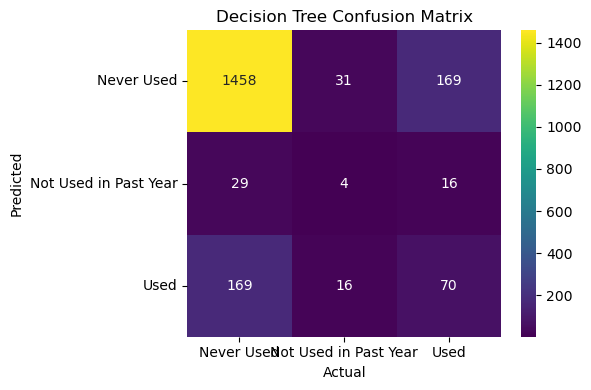

In [227]:
# generate confusion matrix using seaborn
cm_mctree = confusion_matrix_sklearn(y_test2, mctree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_mctree, annot=True, fmt='d', xticklabels=['Never Used', 'Not Used in Past Year', 'Used'], yticklabels=['Never Used', 'Not Used in Past Year', 'Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

Cross-validation is applied to determine the optimal number of terminal nodes for a pruned decision tree model. This pruned model is then applied to the data, plotted, and assessed for its accuracy relative to the unpruned model. A feature importance table is also generated.

In [228]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 50)}
cv_mctree_df = GridSearchCV(mctree_df, params, cv=10)
cv_mctree_df.fit(X_train2, y_train2)
cv_mctree_df_results = cv_mctree_df.cv_results_

# find the best score for max leaf nodes
best_size_mctree = cv_mctree_df.best_params_['max_leaf_nodes']
best_score_mctree = cv_mctree_df.best_score_

best_size_mctree

25

Text(0.5, 1.0, 'Tree Size vs. Cross-Validated Classification Error Rate')

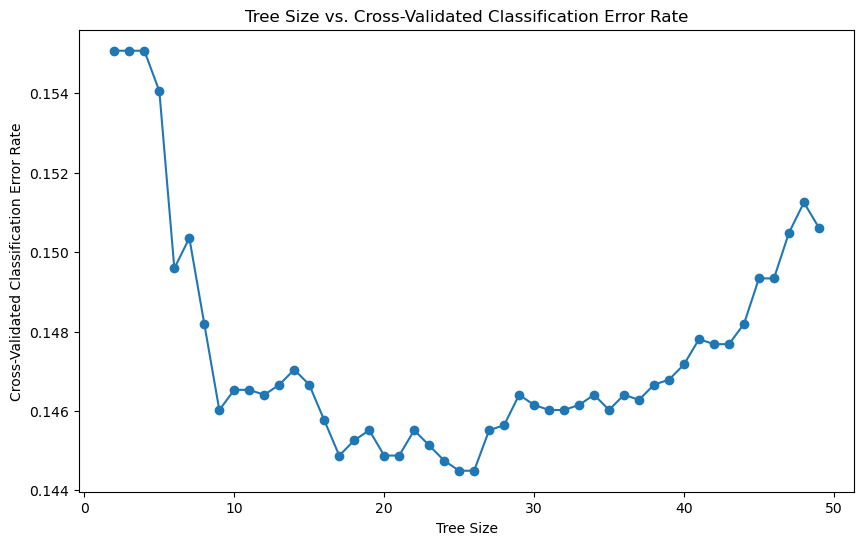

In [229]:
# plot tree size vs cross-validated classification error rate
cv_error_rate_mctree = 1 - cv_mctree_df_results['mean_test_score']

plt.figure(figsize=(10, 6))
plt.plot(cv_mctree_df_results["param_max_leaf_nodes"], cv_error_rate_mctree, marker='o')
plt.xlabel('Tree Size')
plt.ylabel('Cross-Validated Classification Error Rate')
plt.title('Tree Size vs. Cross-Validated Classification Error Rate')

In [231]:
# refit with best size
mctree_df = DecisionTreeClassifier(max_leaf_nodes=25, random_state=1)
mctree_df.fit(X_train2, y_train2)

# predict on test data
mctree_pred = mctree_df.predict(X_test2)

# confusion matrix
confusion_matrix_mctree = pd.crosstab(index=mctree_pred, columns=y_test2, rownames=[''])
print(confusion_matrix_mctree)

# accuracy and error rate
test_accuracy_mctree = mctree_df.score(X_test2, y_test2)
print("Accuracy: {:.2f}%".format(test_accuracy_mctree * 100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_mctree) * 100))

IRMJFY_classes     0   1    2
                             
0               1595  44  199
1                  0   0    3
2                 63   5   53
Accuracy: 84.00%
Error Rate: 16.00%


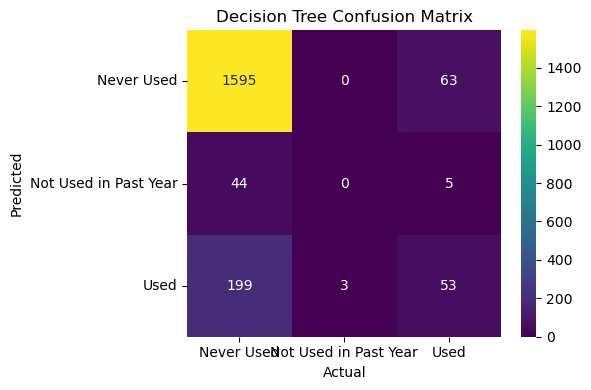

In [234]:
# generate confusion matrix using seaborn
cm_mctree = confusion_matrix_sklearn(y_test2, mctree_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_mctree, annot=True, fmt='d', xticklabels=['Never Used', 'Not Used in Past Year', 'Used'], yticklabels=['Never Used', 'Not Used in Past Year', 'Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

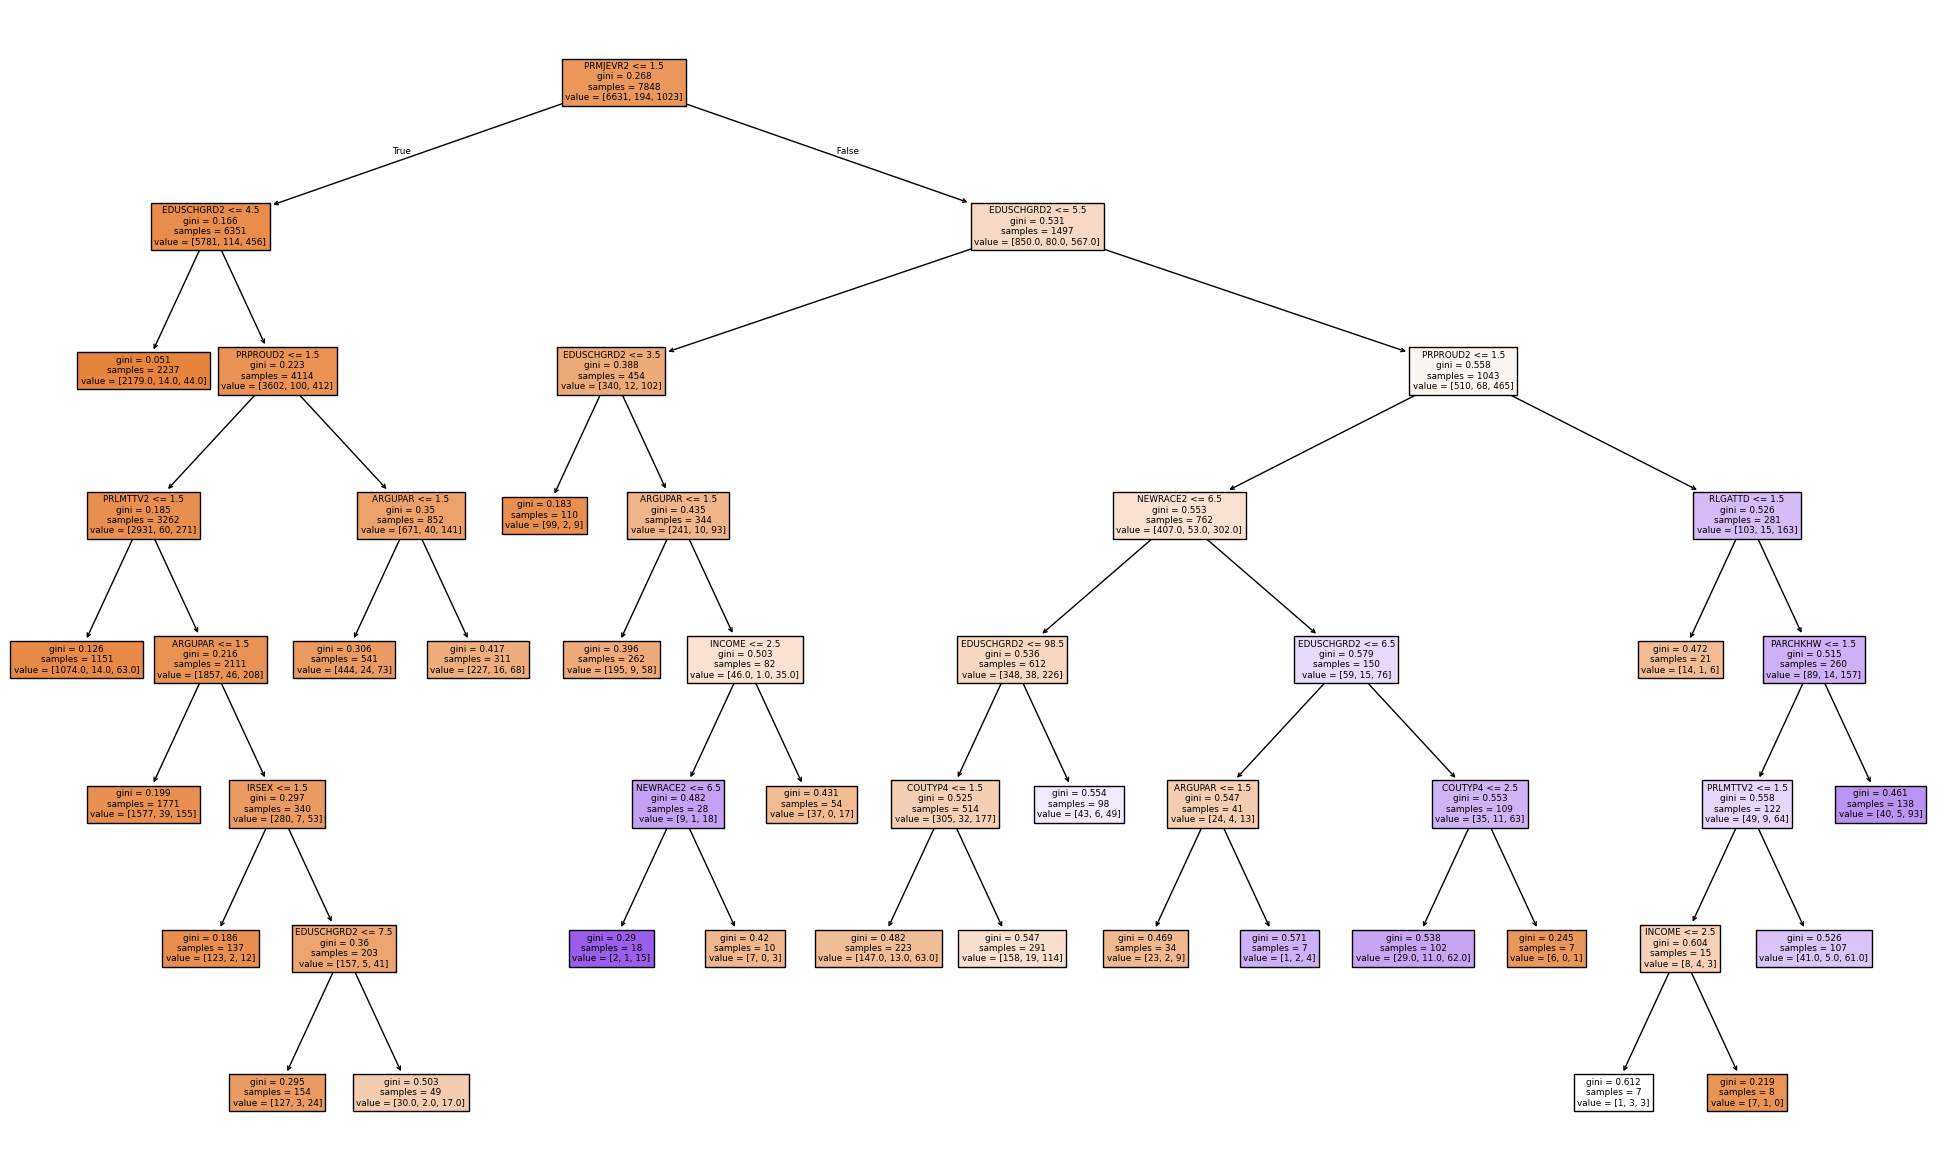

In [232]:
# plot pruned tree
plt.figure(figsize=(25, 15))
plt.title('Pruned Tree')
plot_tree(mctree_df, feature_names=X_train2.columns, filled = True);

In [233]:
importances = pd.DataFrame({'feature_name': X2.columns, 'importance': mctree_df.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0      PRMJEVR2    0.620882
1    EDUSCHGRD2    0.189464
2      PRPROUD2    0.063134
3       ARGUPAR    0.031067
4      NEWRACE2    0.024636
5        INCOME    0.018015
6       COUTYP4    0.016527
7      PRLMTTV2    0.015318
8       RLGATTD    0.009664
9         IRSEX    0.005648
10     PARCHKHW    0.005647
11     PRVDRGO2    0.000000
12     PARHLPHW    0.000000
13     PARLMTSN    0.000000


For the multi-class classification decision tree model, the PRMJEVR2 variable again appears to dominate the features by a wide margin similar to the binary classification model. This model also appeared to struggle with the class 'Not Used in Past Year', failing to correctly predict any of the values in this class. This failure in predictive accuracy could be due to significant class imbalance.

### Applying Random Forest Model

A Random Forest Classifer is applied to the multi-class classification training data using half of the available predictors and inspected for its training score. This model is then used to generate predictions on the test data and examined for its accuracy and error rate. The features are also ranked in terms of their importance scores.

In [235]:
# fit Random Forests model
df1_rfmc = RandomForestClassifier(max_features=7 # reduce features to half of total amount
                                       ,random_state = 1)

df1_rfmc.fit(X_train2, y_train2)

print("Number of trees:", df1_rfmc.n_estimators)
print("Number of features tried at each split:", df1_rfmc.max_features)
print("Training score: {:.2f}%".format(df1_rfmc.score(X_train2, y_train2)*100))

Number of trees: 100
Number of features tried at each split: 7
Training score: 97.30%


In [236]:
# Predict values
y_pred_rfmc = df1_rfmc.predict(X_test2)

# create confusion matrix
confusion_matrix_rfmc = pd.crosstab(index=y_pred_rfmc, columns=y_test2, rownames=[''])
print(confusion_matrix_rfmc)

# calculate test accuracy and error rate
test_accuracy_rfmc = df1_rfmc.score(X_test2, y_test2)
print("Accuracy: {:.2f}%".format(test_accuracy_rfmc*100))
print("Error Rate: {:.2f}%".format((1 - test_accuracy_rfmc)*100))

IRMJFY_classes     0   1    2
                             
0               1560  37  183
1                  9   3    6
2                 89   9   66
Accuracy: 83.03%
Error Rate: 16.97%


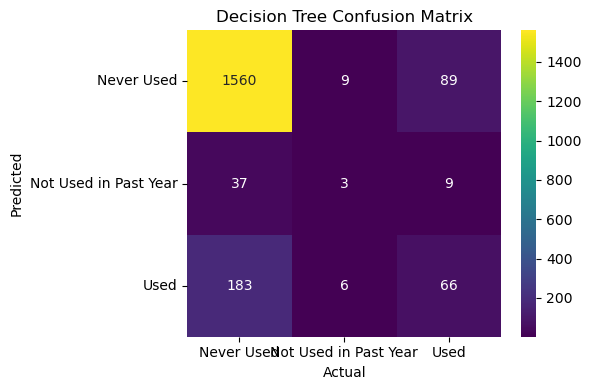

In [237]:
# generate confusion matrix using seaborn
cm_rfmc = confusion_matrix_sklearn(y_test2, y_pred_rfmc)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rfmc, annot=True, fmt='d', xticklabels=['Never Used', 'Not Used in Past Year', 'Used'], yticklabels=['Never Used', 'Not Used in Past Year', 'Used'], cmap='viridis')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.tight_layout()
plt.show()

In [238]:
importances = pd.DataFrame({'feature_name': X2.columns, 'importance': df1_rfmc.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.176236
1      PRMJEVR2    0.126466
2      NEWRACE2    0.119371
3        INCOME    0.111887
4       COUTYP4    0.098585
5         IRSEX    0.056902
6      PARLMTSN    0.055512
7      PARCHKHW    0.050119
8       RLGATTD    0.040474
9       ARGUPAR    0.038156
10     PARHLPHW    0.037502
11     PRLMTTV2    0.033090
12     PRPROUD2    0.030374
13     PRVDRGO2    0.025326


For this random forest model, the top features for predicting marijuana usage are grade level (EDUSCHGRD2), PRMJEVR2 (parental attitudes around youth using marijuana), NEWRACE2 (race/ethnicity), and income (household income level). The model's accuracy fell below that of the pruned decision tree model, though it was able to correctly identify 3 inputs in the 'Not Used in Past Year' class.

## Regression: How old was the respondent when they first used marijuana?

For regression, a standard decision tree model and gradient boosting model are compared for their accuracy in predicting the age at which a respondent first used marijuana based on the chosen predictor variables.

The code below first generates a separate DataFrame to remove observations for respondents who have never used marijuana, before inspecting the distribution of ages of first use. The predictors and target variable are then defined before performing a train-test split on this new DataFrame.

In [239]:
# create DataFrame where respondents who have never used marijuana are removed
df3 = df1[df1['IRMJAGE'] != 991].copy()
df3['IRMJAGE'].value_counts()

IRMJAGE
14    362
15    325
13    286
16    199
12    176
17     59
11     54
10     19
9      16
8      12
7       9
6       2
4       1
5       1
Name: count, dtype: int64

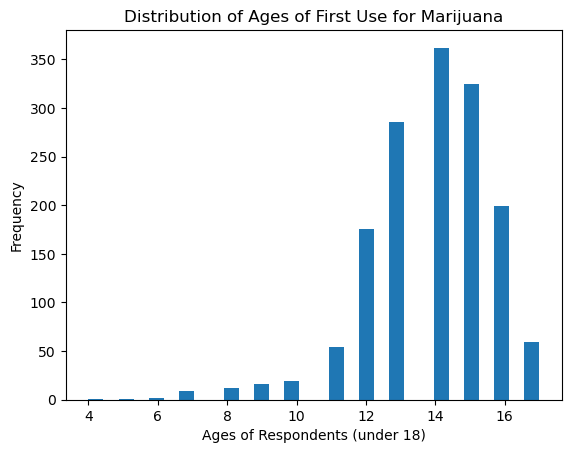

In [240]:
plt.hist(df3['IRMJAGE'], bins=30)
plt.title('Distribution of Ages of First Use for Marijuana')
plt.xlabel('Ages of Respondents (under 18)')
plt.ylabel('Frequency')
plt.show()

In [241]:
# define predictor variables and target variable
X3 = df3[predictors]
y3 = df3['IRMJAGE']

# split the data between test and train
X_train3, X_test3, y_train3, y_test3 = train_test_split(X3, y3
                                                    , train_size=0.8
                                                    , random_state=1)

### Applying Decision Tree Model

Firstly, a Decision Tree Regressor is applied to the new training data and used to generate a plot of the regression tree. This tree model is then inspected for its number of terminal nodes prior to cross-validation. Upon determining the optimal number of terminal nodes, the model is then assessed for its accuracy via the metrics of mean squared error, root mean squared error, and coefficient of determination. A feature importance table is also output for this model.

[Text(0.36764705882352944, 0.9, 'EDUSCHGRD2 <= 5.5\nsquared_error = 3.313\nsamples = 1216\nvalue = 13.909'),
 Text(0.17647058823529413, 0.7, 'EDUSCHGRD2 <= 4.5\nsquared_error = 2.549\nsamples = 262\nvalue = 12.729'),
 Text(0.2720588235294118, 0.8, 'True  '),
 Text(0.11764705882352941, 0.5, 'EDUSCHGRD2 <= 1.5\nsquared_error = 2.663\nsamples = 101\nvalue = 12.01'),
 Text(0.058823529411764705, 0.3, 'squared_error = 0.25\nsamples = 2\nvalue = 8.5'),
 Text(0.17647058823529413, 0.3, 'squared_error = 2.458\nsamples = 99\nvalue = 12.081'),
 Text(0.23529411764705882, 0.5, 'squared_error = 1.949\nsamples = 161\nvalue = 13.18'),
 Text(0.5588235294117647, 0.7, 'EDUSCHGRD2 <= 54.0\nsquared_error = 3.036\nsamples = 954\nvalue = 14.233'),
 Text(0.4632352941176471, 0.8, '  False'),
 Text(0.35294117647058826, 0.5, 'EDUSCHGRD2 <= 6.5\nsquared_error = 2.55\nsamples = 780\nvalue = 14.377'),
 Text(0.29411764705882354, 0.3, 'squared_error = 2.049\nsamples = 238\nvalue = 13.866'),
 Text(0.4117647058823529, 0

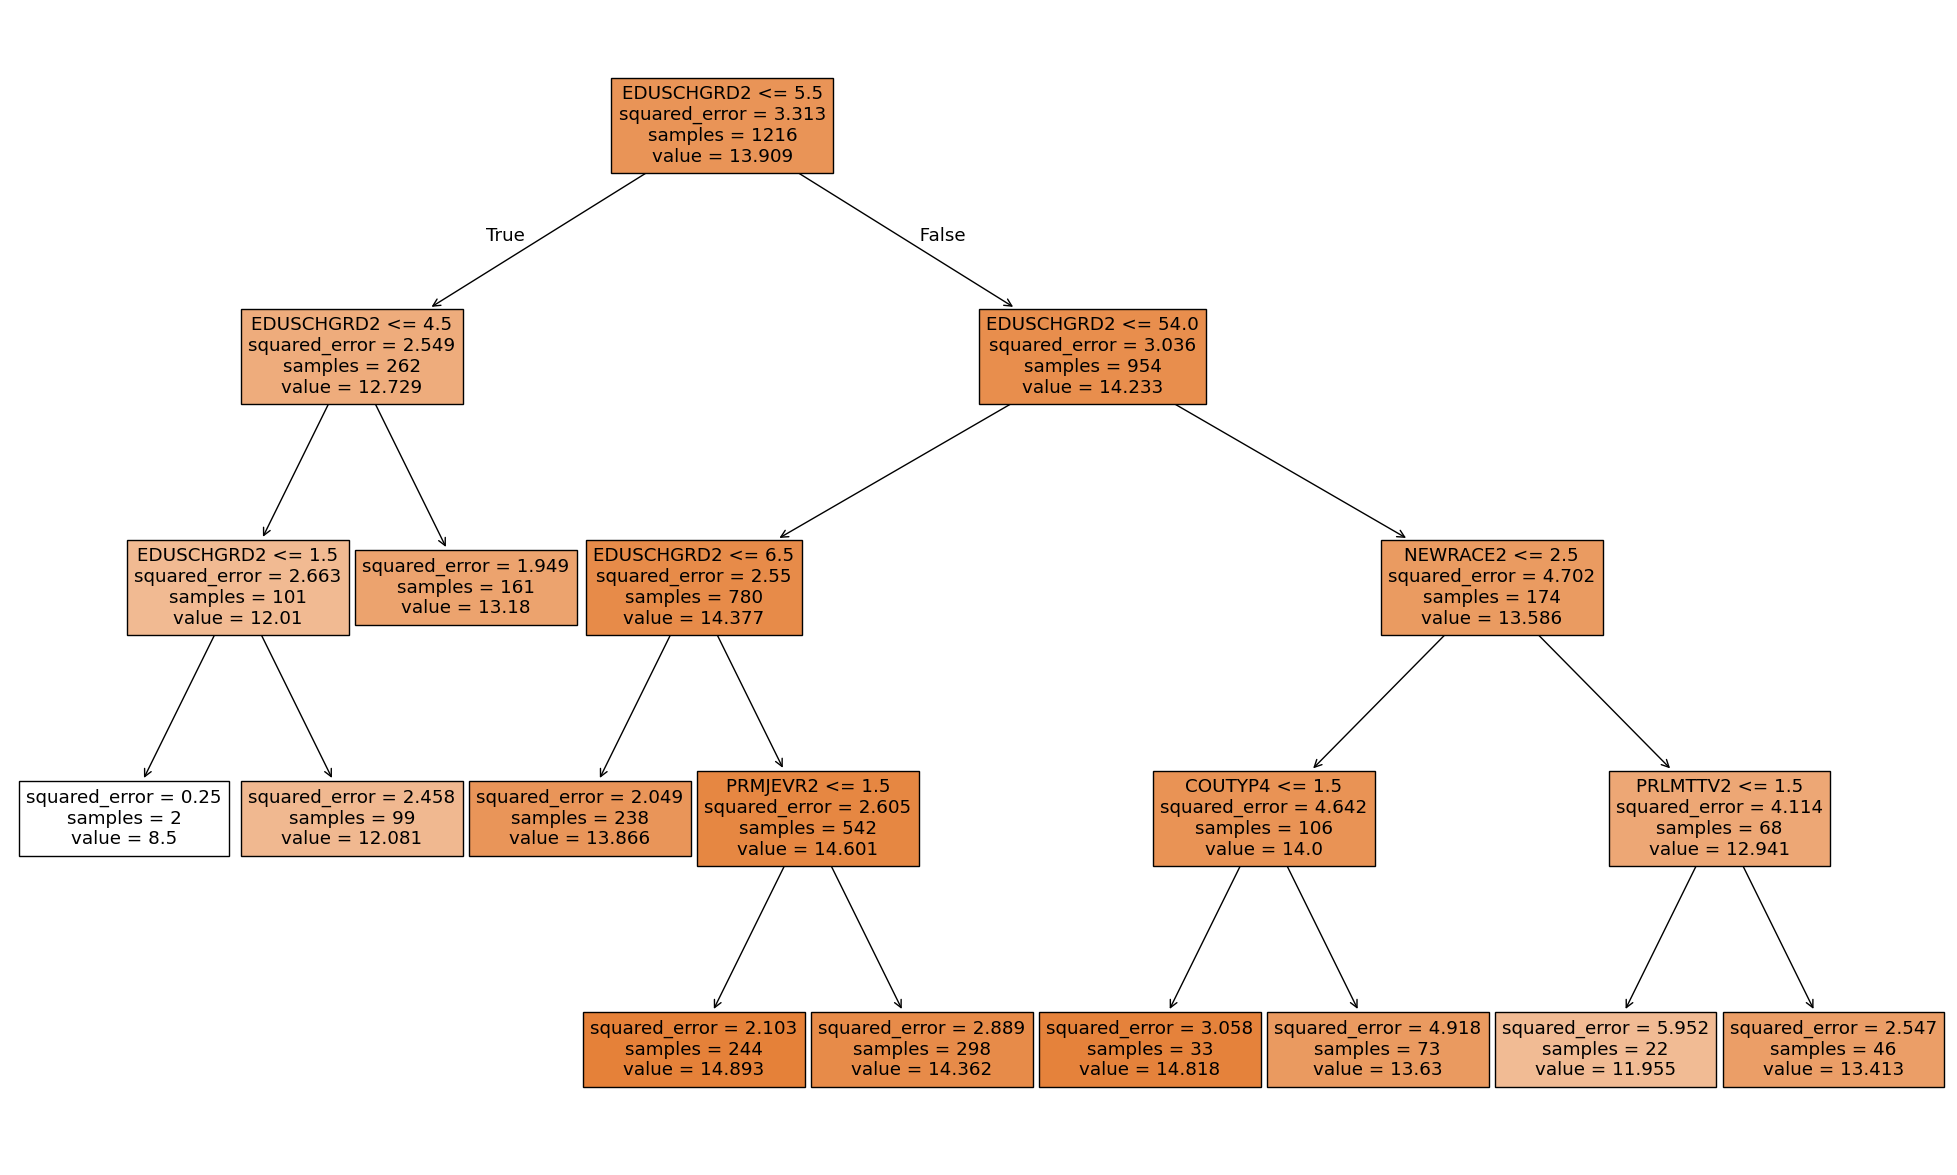

In [242]:
# fit decision tree to training data
tree_df3 = DecisionTreeRegressor(max_leaf_nodes=10, random_state=1)
tree_df3.fit(X_train3, y_train3)

# plot the regression tree
plt.figure(figsize=(25, 15))
plt.title('Age of First Use of Marijuana Regression Tree')
plot_tree(tree_df3, feature_names=X_train3.columns, filled=True)

In [243]:
tree_df3.get_n_leaves()

np.int64(10)

In [244]:
# cross-validation to determine optimal tree size
params = {'max_leaf_nodes': range(2, 50)}
cv_tree_df3 = GridSearchCV(tree_df3, params, cv=10)
cv_tree_df3.fit(X_train3, y_train3)
cv_tree_df3_results = cv_tree_df3.cv_results_

# find the best score for max leaf nodes
best_size_tree_df3 = cv_tree_df3.best_params_['max_leaf_nodes']
best_score_tree_df3 = cv_tree_df3.best_score_

best_size_tree_df3

10

In [245]:
# calculate test MSE and RMSE
MSE = ((y_test3 - tree_df3.predict(X_test3))**2).mean()
print(MSE)
print(np.sqrt(MSE))

2.6142548935597723
1.6168657623809628


In [246]:
np.std(df3['IRMJAGE'])

1.8095406918254384

In [247]:
r2 = r2_score(y_test3, tree_df3.predict(X_test3))
print("R²: {:.4f}".format(r2))

R²: 0.1441


In [248]:
importances = pd.DataFrame({'feature_name': X3.columns, 'importance': tree_df3.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.835807
1      NEWRACE2    0.051521
2      PRMJEVR2    0.041967
3       COUTYP4    0.035585
4      PRLMTTV2    0.035120
5         IRSEX    0.000000
6        INCOME    0.000000
7       RLGATTD    0.000000
8      PRVDRGO2    0.000000
9       ARGUPAR    0.000000
10     PARCHKHW    0.000000
11     PARHLPHW    0.000000
12     PARLMTSN    0.000000
13     PRPROUD2    0.000000


The final decision tree model results in a root mean squared error value that falls below the standard deviation of the target variable IRMJAGE (age of first use of marijuana), suggesting that this model is slightly more predictive than predicting based on the mean value of the data. Additionally, grade level appears to significantly outclass all other features in terms of magnitude of importance.

### Applying Boosting Model

A Gradient Boosting Regressor is applied to the training data before being assessed for its accuracy using the same metrics as before. A lower shrinkage parameter than the default of 0.1 is tested for its accuracy as well, and compared to the final decison tree model.

In [249]:
boost_df3 = GradientBoostingRegressor(n_estimators=1000 # use 1,000 trees 
                                      , learning_rate = 0.1 # default shrinkage parameter
                                      , max_depth = 4
                                      , random_state = 1)
boost_df3.fit(X_train3, y_train3) # fit model to training data

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft

In [250]:
# Predict values
y_pred_boost_df3 = boost_df3.predict(X_test3)

# calculate test MSE and RMSE
MSE = mean_squared_error(y_test3, y_pred_boost_df3)
print(MSE)
print(np.sqrt(MSE))

2.8266561416089995
1.6812662316269245


In [251]:
r2 = r2_score(y_test3, boost_df3.predict(X_test3))
print("R²: {:.4f}".format(r2))

R²: 0.0746


In [252]:
boost_df3 = GradientBoostingRegressor(n_estimators=1000 # use 1,000 trees 
                                      , learning_rate = 0.01 # default shrinkage parameter
                                      , max_depth = 4
                                      , random_state = 1)
boost_df3.fit(X_train3, y_train3) # fit model to training data

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.01
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",1000
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",4
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in thelef

In [253]:
# Predict values
y_pred_boost_df3 = boost_df3.predict(X_test3)

# calculate test MSE and RMSE
MSE = mean_squared_error(y_test3, y_pred_boost_df3)
print(MSE)
print(np.sqrt(MSE))
r2 = r2_score(y_test3, boost_df3.predict(X_test3))
print("R²: {:.4f}".format(r2))

2.4519417354677286
1.5658677260444858
R²: 0.1973


In [254]:
importances = pd.DataFrame({'feature_name': X3.columns, 'importance': boost_df3.feature_importances_})
importances = importances.sort_values('importance', ascending=False).reset_index(drop=True)
print(importances)

   feature_name  importance
0    EDUSCHGRD2    0.446242
1      NEWRACE2    0.106175
2       COUTYP4    0.064711
3        INCOME    0.061793
4      PRMJEVR2    0.045504
5       ARGUPAR    0.043383
6      PRPROUD2    0.035183
7       RLGATTD    0.034717
8      PARHLPHW    0.033811
9      PARLMTSN    0.031634
10     PARCHKHW    0.030298
11     PRLMTTV2    0.029447
12        IRSEX    0.025538
13     PRVDRGO2    0.011564


When setting the shrinkage parameter to 0.01, the boosting model outperformed the model using the default shrinkage parameter value. This secondary boosting model also outperformed the decision tree model in terms of predictive accuracy. Grade level again appeared to be the most important feature/predictor.